In [2]:
import numpy as np
from autoemulate.compare import AutoEmulate
from autoemulate.experimental_design import LatinHypercube
from autoemulate.simulations.projectile import simulate_projectile
from autoemulate.simulations.epidemic import simulate_epidemic
from sklearn.model_selection import KFold
import numpy as np

/Users/mstoffel/turing/misc/presentations/autoemulate-pres/.venv/lib/python3.11/site-packages/autoemulate/compare.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [31]:
def make_gp_data(n_points, x_range=(0, 10), num_basis=20, length_scale=0.5, noise_std=0.1):
    def simple_gp_like_function(x):
        centers = np.random.uniform(x_range[0], x_range[1], num_basis)
        weights = np.random.randn(num_basis)
        dist = np.abs(x[:, np.newaxis] - centers)
        rbf = np.exp(-(dist**2) / (2 * length_scale**2))
        return rbf.dot(weights)

    X = np.random.uniform(x_range[0], x_range[1], n_points)
    y = simple_gp_like_function(X) + np.random.normal(0, noise_std, n_points)
    
    return X.reshape(-1, 1), y

# Generate data
n_points = 100
X, y = make_gp_data(n_points)

In [32]:
em = AutoEmulate()
em.setup(X, y)
em.compare()

,Values
Simulation input shape (X),"(100, 1)"
Simulation output shape (y),"(100,)"
Proportion of data for testing (test_set_size),0.2
Scale input data (scale),True
Scaler (scaler),StandardScaler
Do hyperparameter search (param_search),False
Reduce dimensionality (reduce_dim),False
Cross validator (cross_validator),KFold
Parallel jobs (n_jobs),1


Initializing:   0%|          | 0/8 [00:00<?, ?it/s]

Pipeline(steps=[('scaler', StandardScaler()), ('model', GaussianProcess())])

In [33]:
em.plot_cv(n_cols=4, style="actual_vs_predicted", figsize=(15, 6))
em.summarise_cv()

,model,short,rmse,r2
0,GaussianProcess,gp,0.117707,0.986885
1,RandomForest,rf,0.158115,0.977209
2,GradientBoosting,gb,0.183444,0.969337
3,RadialBasisFunctions,rbf,0.301497,0.913980
4,ConditionalNeuralProcess,cnp,0.407268,0.848206
5,LightGBM,lgbm,0.533318,0.731520
6,SupportVectorMachines,svm,0.567585,0.703973
7,SecondOrderPolynomial,sop,0.792295,0.434281


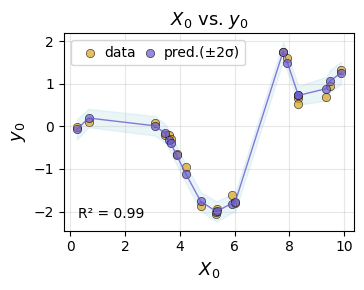

In [40]:
gp = em.get_model("GaussianProcess")
em.plot_eval(gp, figsize=(10, 3))

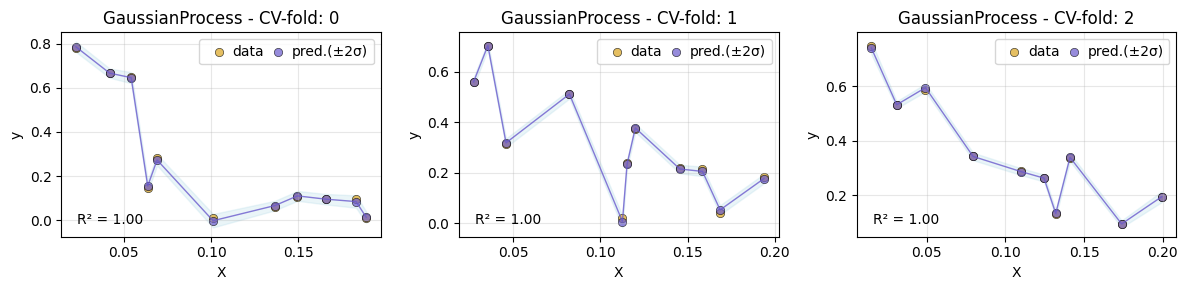

In [45]:
ae.plot_cv(model="GaussianProcess", n_cols=5, figsize=(16,3))
ae.plot_cv(model="GaussianProcess", input_index=1)
